<a href="https://colab.research.google.com/github/saharacodie/insurance_charge_prediction/blob/main/Health_insurance_charge_prediction_ipyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Health Insurance Premium Charges Prediction**

##**MODEL TRAINING**

**CONTENT**

     1. Importing Required Libraries
     2. Load Preprocessed Dataset
     3.  Split x(Features) & y(Target)
     4. Train test split
     5. Feature Scaling
     6. Model Training
     7. Model Testing
     8. Model Evaluation
     


#**1. Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

#**Loading Preprocessed Data**

In [ ]:
# prompt: load /content/Processed_Insurance_data.csv

df = pd.read_csv('/content/Preprocessed Charges.csv')

#**EDA**

In [ ]:

df.head()

,charges,sex,smoker,children,number_of_past_hospitalizations,claim_amount,past_consultations,hospital_expenditure,annual_salary
0,1121.8739,1,0,0,0,29087.54313,17.0,4720920.992,55784970.05
1,1131.5066,1,0,0,0,39053.67437,7.0,4329831.676,13700885.19
2,1135.9407,1,0,0,0,39023.62759,19.0,6884860.774,73523107.27
3,1136.3994,1,0,0,0,28185.39332,11.0,4274773.550,75819679.60
4,1137.0110,1,0,0,0,14697.85941,16.0,3787293.921,23012320.01


In [ ]:
df.isnull().sum().sum()


np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

#**Split X & Y**

In [ ]:
# prompt: split x and y

X = df.drop('charges', axis=1)
y = df['charges']

#**Train Test Split**

In [ ]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed. X_train_scaled and X_test_scaled are now available.")

Feature scaling completed. X_train_scaled and X_test_scaled are now available.


#**Model Training**

In [ ]:
# Initialize the Linear Regression model
model = LinearRegression()
# Fit the model to the training data
model.fit(X_train_scaled, y_train)


LinearRegression()

In [ ]:
print(model.intercept_)
print(model.coef_)

7635.763271649272
[ -29.57930938   65.14701343   81.02503114  991.48338448  123.06329122
  124.93902222  125.6118288  3436.54365085]


#**Model Testing**

In [ ]:
# Make predictions on the testing data
y_pred = model.predict(X_test_scaled)

#**Model Evaluation**

In [ ]:
# Evaluate the model with Test Data
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"R-squared (R2 ): {r2:.2f}")

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared (R2 ): 0.86
Mean Squared Error (MSE): 2862216.89
Root Mean Squared Error (RMSE): 1691.81


The model explains 86% of the variance in the charges, which is excellent for many real world datasets.

#[**Bias Variance TradeOff**](https://drive.google.com/file/d/1JvljwIZAt1Pkx-fJkpmqQ0Dp9uhkZyAr/view?usp=sharing)

In [ ]:
# predict X_train  --> check for underfitting or overfitting

y_train_pred = model.predict(X_train_scaled)

# Evaluate the model
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred)

print(f"R-squared (R2 ): {r2:.2f}")

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared (R2 ): 0.86
Mean Squared Error (MSE): 2658511.95
Root Mean Squared Error (RMSE): 1630.49


In [ ]:
# prompt: predict [[29348.89347, 20.0, 2348575.856, 78675698.05, 1.0, 1] new data
#new_data = np.array([[29348.89347, 20.0, 2348575.856, 78675698.05, 1.0, 1]])

new_data = np.array([[1,0,0,1,29087.54313,17.0, 4720920.992,55784970.05]])

new_data_scaled = scaler.transform(new_data) # Scale the new data

predicted_charge = model.predict(new_data_scaled)

print(f"Predicted charge for the new data: {predicted_charge[0]:.2f}")
#ACTUAL VALUE: 1121.8739

Predicted charge for the new data: 4917.84


we can tune the model using  Gradient Boosting Regressor model or explore regularized linear models (Ridge, Lasso).

#**Model Regularization**

### Ridge and Lasso Regression (Regularization)

Regularization techniques like Ridge and Lasso are used to prevent overfitting by adding a penalty term to the linear regression cost function. This encourages the model to reduce the magnitude of its coefficients.

- **Ridge Regression** (`L2` regularization): Adds a penalty proportional to the square of the magnitude of the coefficients. It helps shrink the coefficients and reduce model complexity, often improving generalization.
- **Lasso Regression** (`L1` regularization): Adds a penalty proportional to the absolute value of the magnitude of the coefficients. A key feature of Lasso is that it can drive some coefficients to exactly zero, effectively performing feature selection.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Ridge Regression
ridge_param_grid = {
    'alpha': np.logspace(-4, 2, 100)  # Alpha values from 0.0001 to 100
}

# Initialize Ridge Regression model
ridge = Ridge(random_state=42)

# Initialize GridSearchCV for Ridge
ridge_grid_search = GridSearchCV(estimator=ridge, param_grid=ridge_param_grid,
                                 scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the scaled training data
ridge_grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and best RMSE for Ridge
best_ridge_params = ridge_grid_search.best_params_
best_ridge_rmse = np.sqrt(-ridge_grid_search.best_score_) # Convert negative MSE to positive RMSE

print(f"Best Parameters for Ridge Regression: {best_ridge_params}")
print(f"Best RMSE from Ridge Grid Search: {best_ridge_rmse:.2f}")

# Evaluate the best Ridge model on the scaled test set
best_ridge_model = ridge_grid_search.best_estimator_
y_test_pred_ridge = best_ridge_model.predict(X_test_scaled)

mse_ridge_test = mean_squared_error(y_test, y_test_pred_ridge)
rmse_ridge_test = np.sqrt(mse_ridge_test)
r2_ridge_test = r2_score(y_test, y_test_pred_ridge)

print(f"Tuned Ridge Regression Test R²: {r2_ridge_test:.2f}")
print(f"Tuned Ridge Regression Test MSE: {mse_ridge_test:.2f}")
print(f"Tuned Ridge Regression Test RMSE: {rmse_ridge_test:.2f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters for Ridge Regression: {'alpha': np.float64(4.037017258596558)}
Best RMSE from Ridge Grid Search: 1653.24
Tuned Ridge Regression Test R²: 0.86
Tuned Ridge Regression Test MSE: 2851072.92
Tuned Ridge Regression Test RMSE: 1688.51


In [ ]:
from sklearn.linear_model import Lasso

# Define the parameter grid for Lasso Regression
lasso_param_grid = {
    'alpha': np.logspace(-4, 2, 100)  # Alpha values from 0.0001 to 100
}

# Initialize Lasso Regression model
lasso = Lasso(random_state=42)

# Initialize GridSearchCV for Lasso
lasso_grid_search = GridSearchCV(estimator=lasso, param_grid=lasso_param_grid,
                                 scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the scaled training data
lasso_grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and best RMSE for Lasso
best_lasso_params = lasso_grid_search.best_params_
best_lasso_rmse = np.sqrt(-lasso_grid_search.best_score_) # Convert negative MSE to positive RMSE

print(f"Best Parameters for Lasso Regression: {best_lasso_params}")
print(f"Best RMSE from Lasso Grid Search: {best_lasso_rmse:.2f}")

# Evaluate the best Lasso model on the scaled test set
best_lasso_model = lasso_grid_search.best_estimator_
y_test_pred_lasso = best_lasso_model.predict(X_test_scaled)

mse_lasso_test = mean_squared_error(y_test, y_test_pred_lasso)
rmse_lasso_test = np.sqrt(mse_lasso_test)
r2_lasso_test = r2_score(y_test, y_test_pred_lasso)

print(f"Tuned Lasso Regression Test R²: {r2_lasso_test:.2f}")
print(f"Tuned Lasso Regression Test MSE: {mse_lasso_test:.2f}")
print(f"Tuned Lasso Regression Test RMSE: {rmse_lasso_test:.2f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters for Lasso Regression: {'alpha': np.float64(24.77076355991714)}
Best RMSE from Lasso Grid Search: 1651.13
Tuned Lasso Regression Test R²: 0.86
Tuned Lasso Regression Test MSE: 2865917.06
Tuned Lasso Regression Test RMSE: 1692.90


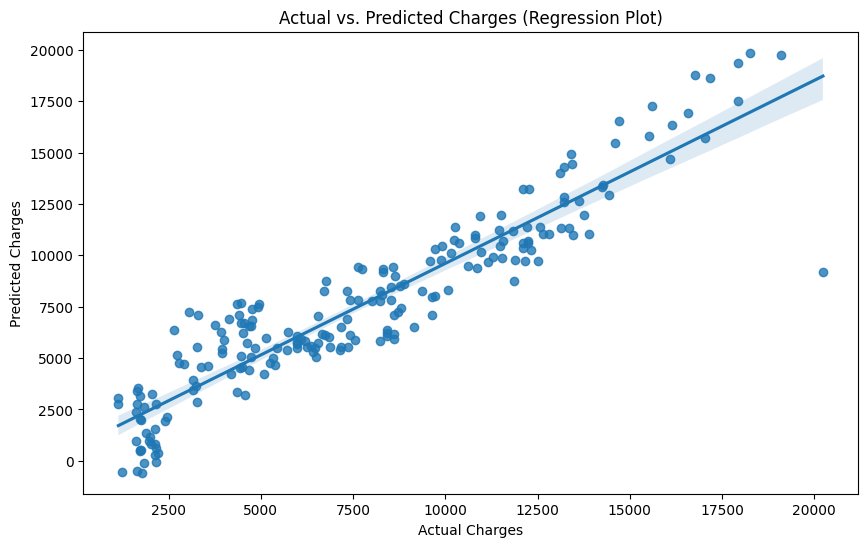

In [ ]:
# regplot for actual values and predicted values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs. Predicted Charges (Regression Plot)")
plt.show()


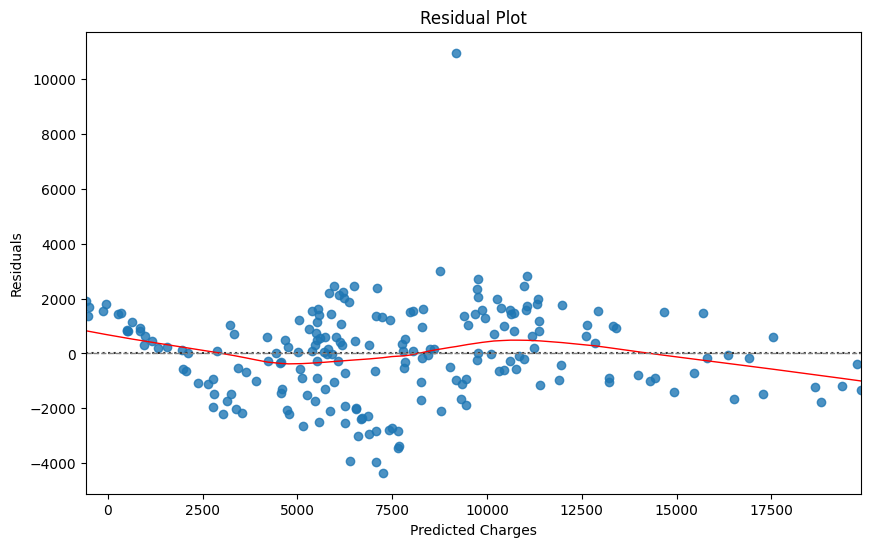

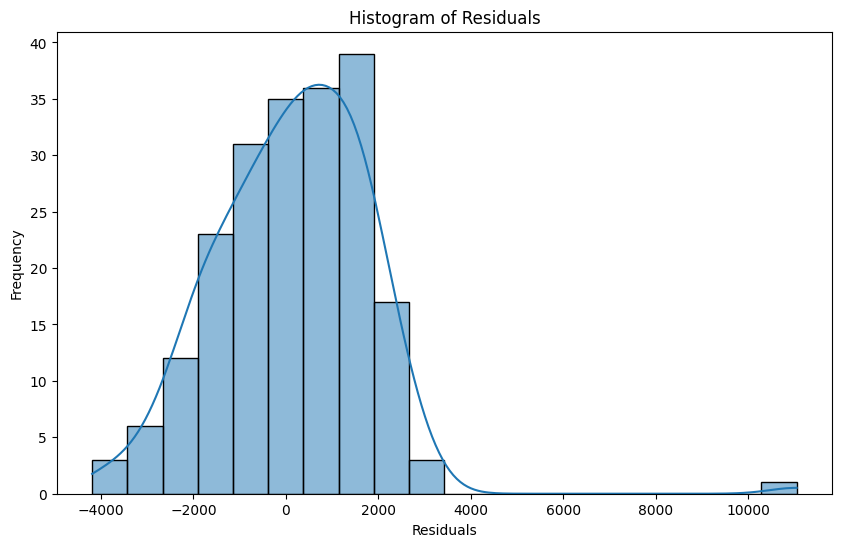

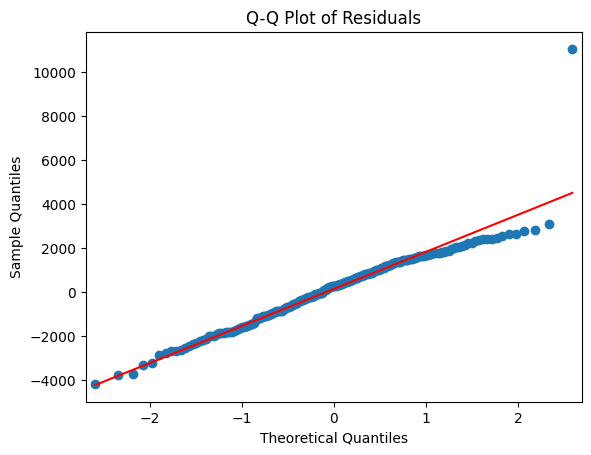

In [ ]:
# prompt: generate residual plots

import matplotlib.pyplot as plt
# Calculate residuals
residuals = y_test - y_pred

# Create a residual plot
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='gray', linestyle='--', lw=1)
plt.show()

# Create a histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# Create a Q-Q plot of residuals to check for normality
import statsmodels.api as sm
fig = sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

In [ ]:
# prompt: generate model parameters

print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [ -29.57930938   65.14701343   81.02503114  991.48338448  123.06329122
  124.93902222  125.6118288  3436.54365085]
Model Intercept: 7635.763271649272


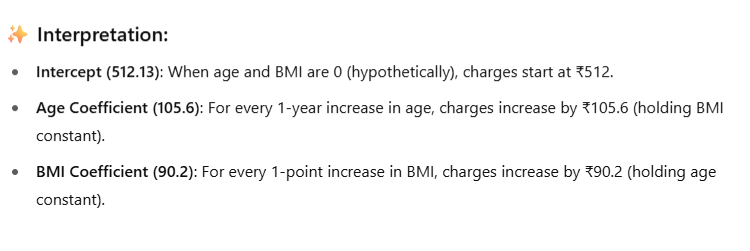

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbm_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.03, max_depth=3,random_state=42)
gbm_reg.fit(X_train, y_train.ravel())


# Make predictions
y_train_pred = gbm_reg.predict(X_train)
y_test_pred = gbm_reg.predict(X_test)

# Evaluate the model
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
rmse_train = np.sqrt(mse_train)

print(f"Training R²: {r2_train:.2f}")
print(f"Testing R²: {r2_test:.2f}")
print(f"Training MSE: {mse_train:.2f}")
print(f"Testing MSE: {mse_test:.2f}")
print(f"Training RMSE: {rmse_train:.2f}")
print(f"Testing RMSE: {rmse_test:.2f}")
#[100,0.01],[100,0.03,3 best],[500,0.05][500,0.02],[100,0.07]

Training R²: 0.91
Testing R²: 0.91
Training MSE: 1801458.35
Testing MSE: 1788397.35
Training RMSE: 1342.18
Testing RMSE: 1337.31


In [ ]:
# prompt: save the model using joblib
import joblib

# Save the trained model to a file
joblib.dump(gbm_reg, 'insurance_model.joblib')

['insurance_model.joblib']

In [ ]:
# prompt: predict [[29348.89347, 20.0, 2348575.856, 78675698.05, 1.0, 1] new data
#new_data = np.array([[29348.89347, 20.0, 2348575.856, 78675698.05, 1.0, 1]])

new_data = np.array([[1,0,0,0,29087.54313,17.0, 4720920.992,55784970.05]])

#new_data_scaled = scaler.transform(new_data) # Scale the new data

predicted_charge = gbm_reg.predict(new_data)

print(f"Predicted charge for the new data: {predicted_charge[0]:.2f}")
#ORIGINAL VALUE:1121.8739

Predicted charge for the new data: 2234.79
